In [1]:
import numpy as np
import yaml
import os
from classy import Class
import matplotlib.pyplot as plt
from pybird.correlator import Correlator
from pybird_master.correlator import Correlator as master_Correlator

from pybird import common as co
from pybird.likelihood import Likelihood
from pybird.io_pb import ReadWrite



# config settings

In [2]:
# the EOS
#w = [-1.6,-0.7]
w = [-1.6,-1.,-0.7,-0.45]#np.linspace(-2,-0.4,4)
w0 = w#[-1.2,-1.,-0.7,-0.45]
wa = [-1.8,-1.2,-0.8,0.]
#wa = [-1.2,-0.2]
#alist=[0.6,1/(1+0.1)]
#zlist = [1/alist[i]-1 for i in range(len(alist))]
zlist = [0.32,0.57]
#zlist= [0.32]
alist = [1/(1.+z) for z in zlist]
print('redshift=',zlist,alist)

redshift= [0.32, 0.57] [0.7575757575757576, 0.6369426751592357]


In [3]:
km=0.7
paperbias={'b1':2.4,'b2':-0.4,'b3':2.1,'b4':0,'cct':0,'cr1':-8.6*km**2,'cr2':0,
           'ce0':1.4,'ce1':-4.3*km**2,'ce2':0}  # https://arxiv.org/pdf/2005.04805 fig3
guessbias = {'b1':2.,'b2':1.,'b4':1,'Bb1':2,'Bb2':1.,'Bb5':1.}
minbias={'b1': 2.0417, 'Bb2': 1.7411, 'Bb5': 0.6181, 'Bb3': 1.8072, 
      'Bc1': 5.0697, 'Bc2': -1.5640, 'Bc3': 1.1729, 
      'Be1': 0.0475, 'Be2': 3.0114, 'ce2': -1.4731, 
      'Bb4': 0.1639, 'Bb6': 0.9556, 'Bb7': 0.3585, 'Bb8': -0.4802, 'Bb9': 0.2262, 'Bb10': -2.1871, 'Bb11': -1.7619, 
      'Bc4': -0.1628, 'Bc5': -0.3192, 'Bc6': 1.4350, 'Bc7': 0.7985, 'Bc8': 0.4208, 'Bc9': 0.2500, 'Bc10': 0.2752, 'Bc11': 0.9740, 'Bc12': 0.2877, 'Bc13': 0.0925, 'Bc14': 1.1125, 
      'Bd1': 0.1716, 'Bd2': 1.4660, 'Bd3': -0.0000, 'Be3': 0.0775, 'Be4': -0.0157, 'Be5': 0.6205, 'Be6': -0.4740, 'Be7': -0.4299, 'Be8': 0.3059, 'Be9': 0.2075, 'Be10': 0.2194, 'Be11': 0.1628, 'Be12': 0.0898, 'cr4': 0.0000, 'cr6': 0.0000, 
      'Bb1': 2.0417, 'b2': 1.7411, 'b3': -5.3962, 'b4': 0.6181, 
         'cct': -5.0697, 'cr1': -1.1709, 'cr2': -0.3571, 'ce0': 0.0475, 'ce1': 2.2749}
bestbias={'b1': 1.9542, 'c2': 0.5904, 'c4': 0.0, 'b3': -0.3687, 'cct': 0.1825, 'cr1': -0.8476, 'cr2': -0.8134, 'ce0': 1.4985, 'ce1': 0.0, 'ce2': -1.6364, 'b2': 0.4175, 'b4': 0.4175}

In [4]:
def get_cosmo_at_z(z,w0,wa=0):
    M = Class()
    cosmo1 = {'omega_b': 0.02235, 'omega_cdm': 0.120, 'h': 0.675, 'ln10^{10}A_s': 3.044, 'n_s': 0.965}
    if w0 is not None:
        cosmo1.update({'Omega_Lambda':0,
              'w0_fld':w0,
            'wa_fld':wa})
    M.set(cosmo1)
    M.set({'output': 'mPk', 'P_k_max_h/Mpc': 10, 'z_max_pk': z})
    M.compute()
    kk = np.logspace(-5, 0, 200)
    pk_lin = np.array([M.pk_lin(k*M.h(), z)*M.h()**3 for k in kk]) 
    D1, f1 = M.scale_independent_growth_factor(z), M.scale_independent_growth_factor_f(z)
    return M,kk,pk_lin,D1,f1

In [5]:

def get_spectrum(setting_dict,z,eft_params,test_master=False,Eds=False,w0_fld=-1.,wa_fld=0.,with_quintessence=False):
    M,kk,pk_lin,D1,f1 = get_cosmo_at_z(z,w0_fld,wa_fld)
    setting_dict['z']=z
    if Eds:
        setting_dict['with_exact_time']=False
    else:
        setting_dict['with_exact_time']=True
        
    setting_dict['with_quintessence']=with_quintessence

    if test_master:
        N = master_Correlator()
    else:
        N = Correlator()
    N.set(setting_dict)
    cosmo = {'omega_b': 0.02235, 'omega_cdm': 0.120, 'h': 0.675, 'ln10^{10}A_s': 3.044, 'n_s': 0.965}

    if test_master:
        N.compute({'w0_fld':w0_fld},cosmo_module='class',cosmo_engine=M)
    else:
        N.compute({'w0_fld':w0_fld,'wa_fld':wa_fld},cosmo_module='class',cosmo_engine=M)
    #N.compute({'w0_fld':w0_fld},cosmo_module='class',cosmo_engine=M)

    spectrum_full=N.get(eft_params,what='full')
    
    return spectrum_full



In [6]:
def get_triangle_shape(tridata):
    kf = tridata['kf']
    tn = tridata['tn']
    tri = tn*kf
    n1,n2,n3 = tn
    k1,k2,k3 = tri
    zero_area = np.argwhere((n1 == n2 + n3))[:, 0]
    equilateral = np.argwhere((n1 == n2) & (n1 == n3))[:, 0]
    isoceles = np.argwhere(((n1 != n2) & (n2 == n3)) | ((n1 == n2) & (n2 != n3)))[:, 0]
    scalene = np.argwhere((n1 != n2) & (n1 != n3) & (n2 != n3))[:, 0]
    return equilateral,isoceles,scalene

In [7]:
dk, ds = 0.01, 5
kd = np.arange(0.005, 0.3, dk)
sd = np.arange(10, 200, ds)
ps_master={
    'output': 'bPk', 'multipole': 2, 'kmax': 0.3,
    'km': 0.7, 'kr': 0.35, 'nd': 3e-4, 
    'eft_basis': 'eftoflss', 'with_stoch': True, 
    'with_resum':True,  # for quicker comparsion
    'xdata':kd,
    
}


In [8]:
bconfig = yaml.full_load(open('boss_pybird_bk.yaml','r'))
br= ReadWrite()
bd,bfc,bfd=br.read(bconfig)
triangle = bfc[0]['triangle_data']

equilateral,_,_ = get_triangle_shape(triangle)

reading data file: /Users/zhiyulu/Documents/Github/pybird_emu_bisp/data/eftboss/boss_12kf3pt_6kf2pt.h5
-----------------------
sky: cmass_ngc
output: bBk
-----------------------


/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/io_pb.py:141: UserWarning: Be cautions with above min max
  warnings.warn("Be cautions with above min max", UserWarning)
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/io_pb.py:286: UserWarning: please use the same kcut
  warnings.warn('please use the same kcut')


In [9]:
# bispectrum tree set





Dfid=0.3133754466547983
Hfid=1.3718053425836065
Omegamfid=0.31


bs={
    'output': 'bBk', #'multipole': 3, 'xdata':kd,
    'eft_basis': 'eftoflss',
    'with_stoch': False,
    'with_nnlo_counterterm':False,

    
    'with_time':True,
    'with_exact_time':True,
    'with_survey_mask':False,

    
   # for bispectrum
   'tree_level':True,
    'bisp_resum':True,
    'bisp_quad':0,
   'triangle_data':triangle,
    'matrix_path':'/Users/zhiyulu/Documents/Science/Cosmology_data/eftboss_bisp_mat/loop_mat_keff_12kf.h5',

    'with_ap':False,
    'with_quintessence':False

}

# Exact/eds

## bspectrum

In [10]:
eds_bk_wcdm = [[get_spectrum(bs,zlist[i],minbias,test_master=False,w0_fld=iw,Eds=True,with_quintessence=False) for i in range(len(zlist))] for iw in w]
ex_bk_wcdm = [[get_spectrum(bs,zlist[i],minbias,test_master=False,w0_fld=iw,Eds=False,with_quintessence=False) for i in range(len(zlist))] for iw in w]

eds_bk_w0wa = [[[get_spectrum(bs,zlist[i],minbias,test_master=False,w0_fld=iw0,wa_fld=iwa,Eds=True,with_quintessence=False) for i in range(len(zlist))] for iwa in wa] for iw0 in w0]
ex_bk_w0wa = [[[get_spectrum(bs,zlist[i],minbias,test_master=False,w0_fld=iw0,wa_fld=iwa,Eds=False,with_quintessence=False) for i in range(len(zlist))] for iwa in wa] for iw0 in w0]



Loaded loop matrices do not correspond to asked FFTLog configuration. 
 Computing new matrices.


/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/nonlinear_bisp.py:224: UserWarning: How to get these numbers
  warnings.warn('How to get these numbers')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/nonlinear_bisp.py:912: UserWarning: not understood
  warnings.warn('not understood')


bispectrum_nl: Loading bisp...
bispectrum_nl: Bisp loaded!
setting EdS time approximation
bispectrum_nl: Loading bisp...
bispectrum_nl: Bisp loaded!


/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:529: UserWarning: what's following setting?
  warnings.warn("what's following setting?")
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/nonlinear_bisp.py:476: UserWarning: wrong cacluclation of bispquad!!! please check pyowl bispectrum_nl_quad
  warnings.warn('wrong cacluclation of bispquad!!! please check pyowl bispectrum_nl_quad')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:547: UserWarning: whats the uvmatch and irsub?
  warnings.warn("whats the uvmatch and irsub?")
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:1343: UserWarning: Whats the relationship between ce2 and Bb
  warnings.warn('Whats the relationship between ce2 and Bb')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:1365: UserWarning: decommont following if necessary
  warnings.warn('decommont following if necessary')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/bird.

setting EdS time approximation
bispectrum_nl: Loading bisp...
bispectrum_nl: Bisp loaded!
setting EdS time approximation


...

/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:529: UserWarning: what's following setting?
  warnings.warn("what's following setting?")
/Users/zhiyulu/Document

bispectrum_nl: Loading bisp...
bispectrum_nl: Bisp loaded!


/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:529: UserWarning: what's following setting?
  warnings.warn("what's following setting?")
/Users/zhiyulu/Document

bispectrum_nl: Loading bisp...
bispectrum_nl: Bisp loaded!


/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:529: UserWarning: what's following setting?
  warnings.warn("what's following setting?")
/Users/zhiyulu/Document

Text(0.5, 0.98, 'ratio between exact_time and eds for wcdm(left) and w0wa(right)')

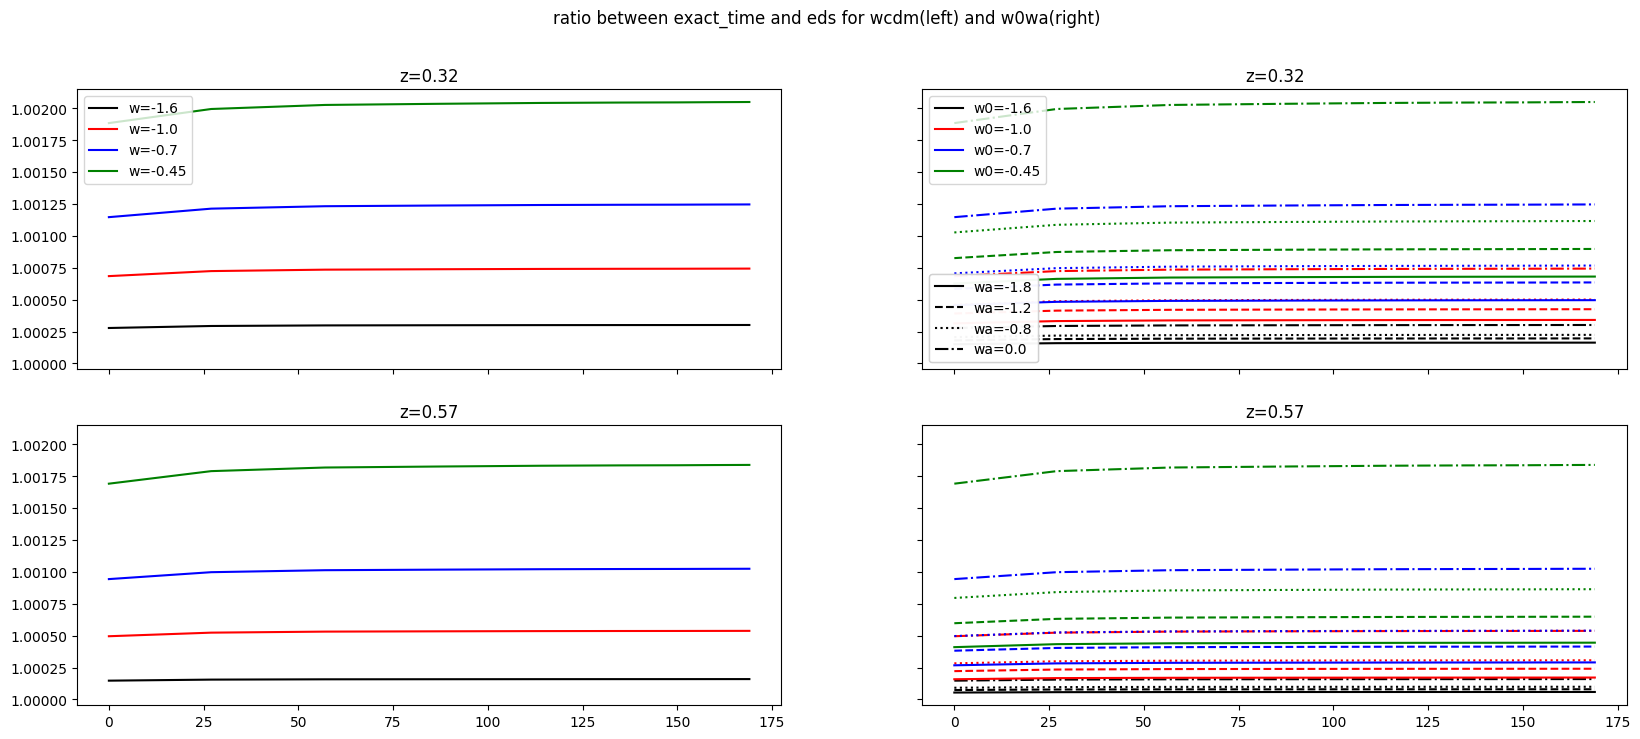

In [11]:
f,ax=plt.subplots(2,2,figsize=(20,8),sharex=True,sharey=True)
l=0
color=['k','r','b','g']

# wcdm
for iw in range(len(w)):
    for iz in range(len(zlist)):
        ax[iz][0].plot(equilateral,(ex_bk_wcdm[iw][iz][0][0]/eds_bk_wcdm[iw][iz][0][0])[equilateral],color=color[iw],label='w={}'.format(w[iw]))
        #ax[iz].plot(kd,(ex_pk_wcdm[iw][iz][1]/eds_pk_wcdm[iw][iz][1]),'--',color=color[iw])
        ax[iz][0].set_title('z={:.2f}'.format(zlist[iz]))


ax[0][0].legend()


# w0wa
linestyle=['-','--',':','-.']
line=[]
for iw0 in range(len(w0)):
    for iwa in range(len(wa)):
        for iz in range(len(zlist)):
            li = ax[iz][1].plot(equilateral,(ex_bk_w0wa[iw0][iwa][iz][0][0]/eds_bk_w0wa[iw0][iwa][iz][0][0])[equilateral],color=color[iw0],linestyle=linestyle[iwa],label='w0={},wa={}'.format(w0[iw0],wa[iwa]))
            line.append(li[0])

ax[0][1].set_title('z={:.2f}'.format(zlist[0]))
ax[1][1].set_title('z={:.2f}'.format(zlist[1]))


legbase = ax[0][1].legend([line[i*len(wa)*len(zlist)] for i in range(len(w0))],['w0={}'.format(w0[i]) for i in range(len(w0))],loc=2)
ax[0][1].add_artist(legbase)


legbase = ax[0][1].legend([line[2*i] for i in range(len(wa))],['wa={}'.format(wa[i]) for i in range(len(wa))],loc=3,handlelength=2)
ax[0][1].add_artist(legbase)


f.suptitle('ratio between exact_time and eds for wcdm(left) and w0wa(right)')

In [ ]:
covmat

# cq vs sq

In [20]:
1/np.exp(-12)-1

162753.79141900392

In [12]:
ex_bk_lcdm_cq = [get_spectrum(bs,zlist[i],minbias,test_master=False,w0_fld=-1.,wa_fld=0.,Eds=False,with_quintessence=True) for i in range(len(zlist))]
ex_bk_wcdm_cq = [[get_spectrum(bs,zlist[i],minbias,test_master=False,w0_fld=iw,wa_fld=0.,Eds=False,with_quintessence=True) for i in range(len(zlist))] for iw in w]
ex_bk_w0wa_cq = [[[get_spectrum(bs,zlist[i],minbias,test_master=False,w0_fld=iw0,wa_fld=iwa,Eds=False,with_quintessence=True) for i in range(len(zlist))] for iwa in wa] for iw0 in w0]


/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/nonlinear_bisp.py:224: UserWarning: How to get these numbers
  warnings.warn('How to get these numbers')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/nonlinear_bisp.py:912: UserWarning: not understood
  warnings.warn('not understood')
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


bispectrum_nl: Loading bisp...
bispectrum_nl: Bisp loaded!


/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. 

bird birsp_resum 0.9999907450947454
bispectrum_nl: Loading bisp...
bispectrum_nl: Bisp loaded!


/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:529: UserWarning: what's following setting?
  warnings.warn("what's following setting?")
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/nonlinear_bisp.py:476: UserWarning: wrong cacluclation of bispquad!!! please check pyowl bispectrum_nl_quad
  warnings.warn('wrong cacluclation of bispquad!!! please check pyowl bispectrum_nl_quad')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:547: UserWarning: whats the uvmatch and irsub?
  warnings.warn("whats the uvmatch and irsub?")
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:1343: UserWarning: Whats the relationship between ce2 and Bb
  warnings.warn('Whats the relationship between ce2 and Bb')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:1365: UserWarning: decommont following if necessary
  warnings.warn('decommont following if necessary')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/bird.

...

/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:529: UserWarning: what's following setting?
  warnings.warn("what's following setting?")
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/nonlinear_bisp.py:476: UserWarning: wrong cacluclation of bispquad!!! please check pyowl bispectrum_nl_quad
  warnings.warn('wrong cacluclation of bispquad!!! please check pyowl bispectrum_nl_quad')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:547: UserWarning: whats the uvmatch and irsub?
  warnings.warn("whats the uvmatch and irsub?")
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:1343: UserWarning: Whats the relationship between ce2 and Bb
  warnings.warn('Whats the relationship between ce2 and Bb')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:1365: UserWarning: decommont following if necessary
  warnings.warn('decommont following if necessary')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/bird.

bird birsp_resum 0.7713498930309568
bispectrum_nl: Loading bisp...
bispectrum_nl: Bisp loaded!


/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:529: UserWarning: what's following setting?
  warnings.warn("what's following setting?")
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/nonlinear_bisp.py:476: UserWarning: wrong cacluclation of bispquad!!! please check pyowl bispectrum_nl_quad
  warnings.warn('wrong cacluclation of bispquad!!! please check pyowl bispectrum_nl_quad')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:547: UserWarning: whats the uvmatch and irsub?
  warnings.warn("whats the uvmatch and irsub?")
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:1343: UserWarning: Whats the relationship between ce2 and Bb
  warnings.warn('Whats the relationship between ce2 and Bb')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:1365: UserWarning: decommont following if necessary
  warnings.warn('decommont following if necessary')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/bird.

bird birsp_resum 0.8056389762133371


/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:529: UserWarning: what's following setting?
  warnings.warn("what's following setting?")
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/nonlinear_bisp.py:476: UserWarning: wrong cacluclation of bispquad!!! please check pyowl bispectrum_nl_quad
  warnings.warn('wrong cacluclation of bispquad!!! please check pyowl bispectrum_nl_quad')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:547: UserWarning: whats the uvmatch and irsub?
  warnings.warn("whats the uvmatch and irsub?")
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:1343: UserWarning: Whats the relationship between ce2 and Bb
  warnings.warn('Whats the relationship between ce2 and Bb')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:1365: UserWarning: decommont following if necessary
  warnings.warn('decommont following if necessary')
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/bird.

Text(0.5, 0.98, 'bispectrum: ratio between exact_time and eds for wcdm(left) and w0wa(right)')

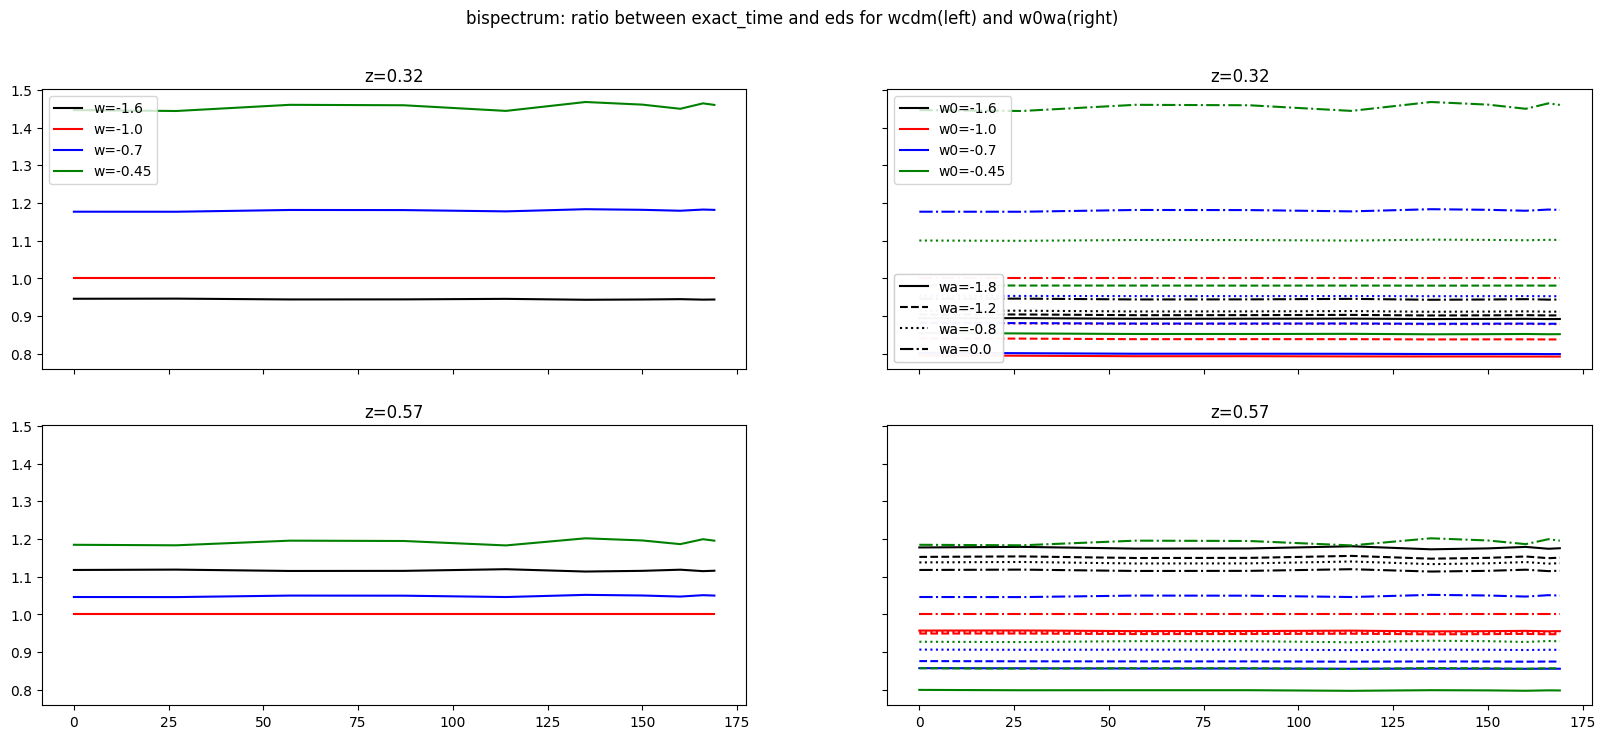

In [13]:
f,ax=plt.subplots(2,2,figsize=(20,8),sharex=True,sharey=True)
l=0
color=['k','r','b','g']

# wcdm
for iw in range(len(w)):
    for iz in range(len(zlist)):
        ax[iz][0].plot(equilateral,(ex_bk_wcdm_cq[iw][iz][0][0]/ex_bk_lcdm_cq[iz][0][0])[equilateral],color=color[iw],label='w={}'.format(w[iw]))
        #ax[iz].plot(kd,(ex_pk_wcdm[iw][iz][1]/eds_pk_wcdm[iw][iz][1]),'--',color=color[iw])
        ax[iz][0].set_title('z={:.2f}'.format(zlist[iz]))


ax[0][0].legend()


# w0wa
linestyle=['-','--',':','-.']
line=[]
for iw0 in range(len(w0)):
    for iwa in range(len(wa)):
        for iz in range(len(zlist)):
            li = ax[iz][1].plot(equilateral,(ex_bk_w0wa_cq[iw0][iwa][iz][0][0]/ex_bk_lcdm_cq[iz][0][0])[equilateral],color=color[iw0],linestyle=linestyle[iwa],label='w0={},wa={}'.format(w0[iw0],wa[iwa]))
            line.append(li[0])

ax[0][1].set_title('z={:.2f}'.format(zlist[0]))
ax[1][1].set_title('z={:.2f}'.format(zlist[1]))


legbase = ax[0][1].legend([line[i*len(wa)*len(zlist)] for i in range(len(w0))],['w0={}'.format(w0[i]) for i in range(len(w0))],loc=2)
ax[0][1].add_artist(legbase)


legbase = ax[0][1].legend([line[2*i] for i in range(len(wa))],['wa={}'.format(wa[i]) for i in range(len(wa))],loc=3,handlelength=2)
ax[0][1].add_artist(legbase)


f.suptitle('bispectrum: ratio between exact_time and eds for wcdm(left) and w0wa(right)')

# cq vs eds

Text(0.5, 0.98, 'bispectrum: wcdm-cq/wcdm-eds(left) and w0wa-cq/w0wa-eds(right)')

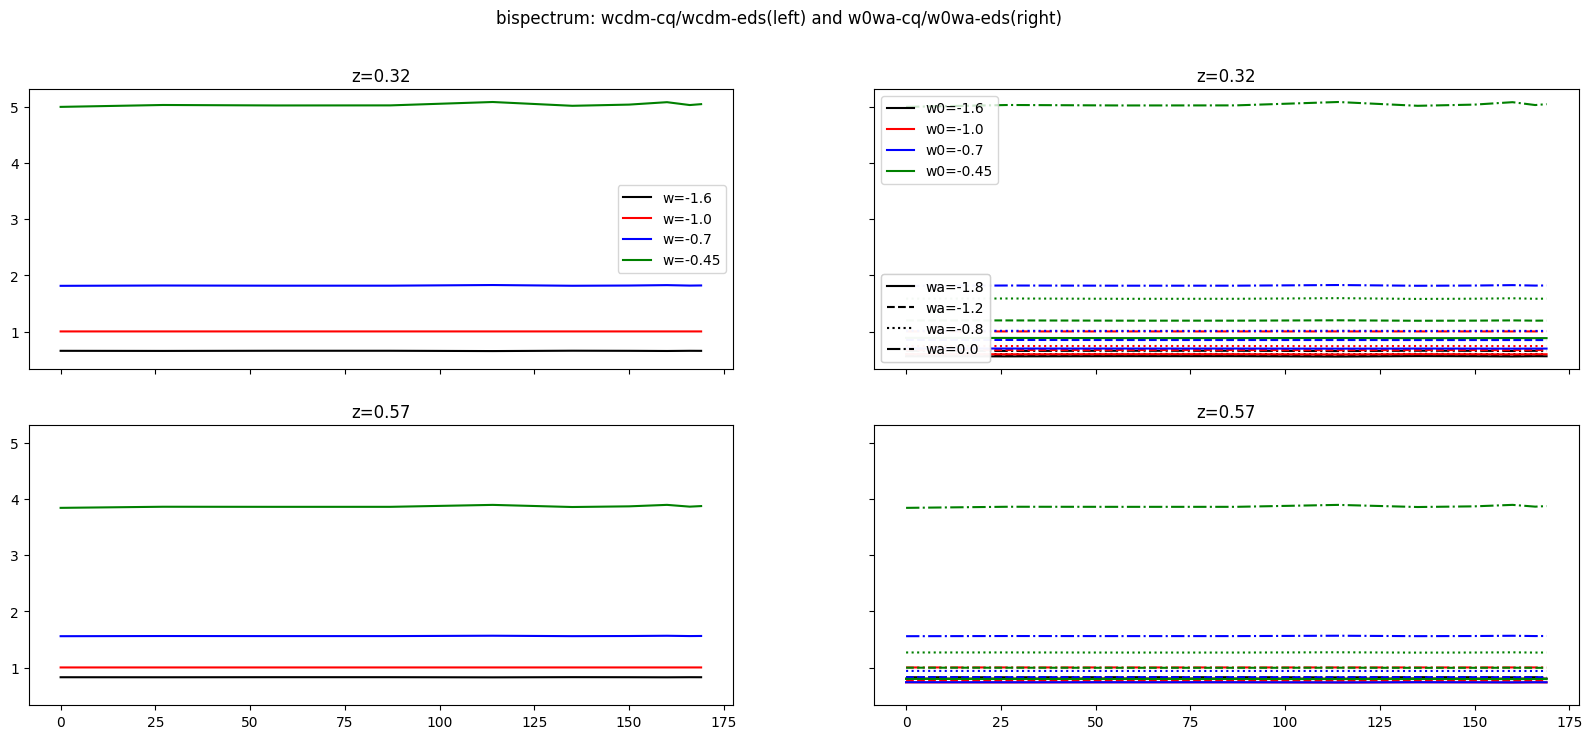

In [14]:


f,ax=plt.subplots(2,2,figsize=(20,8),sharex=True,sharey=True)
l=0
color=['k','r','b','g']

# wcdm
for iw in range(len(w)):
    for iz in range(len(zlist)):
        ax[iz][0].plot(equilateral,(ex_bk_wcdm_cq[iw][iz][0][0]/eds_bk_wcdm[iw][iz][0][0])[equilateral],color=color[iw],label='w={}'.format(w[iw]))

        ax[iz][0].set_title('z={:.2f}'.format(zlist[iz]))


ax[0][0].legend()


# w0wa
linestyle=['-','--',':','-.']
line=[]
for iw0 in range(len(w0)):
    for iwa in range(len(wa)):
        for iz in range(len(zlist)):
            li = ax[iz][1].plot(equilateral,(ex_bk_w0wa_cq[iw0][iwa][iz][0][0]/eds_bk_w0wa[iw0][iwa][iz][0][0])[equilateral],color=color[iw0],linestyle=linestyle[iwa],label='w0={},wa={}'.format(w0[iw0],wa[iwa]))
            line.append(li[0])

ax[0][1].set_title('z={:.2f}'.format(zlist[0]))
ax[1][1].set_title('z={:.2f}'.format(zlist[1]))


legbase = ax[0][1].legend([line[i*len(wa)*len(zlist)] for i in range(len(w0))],['w0={}'.format(w0[i]) for i in range(len(w0))],loc=2)
ax[0][1].add_artist(legbase)


legbase = ax[0][1].legend([line[2*i] for i in range(len(wa))],['wa={}'.format(wa[i]) for i in range(len(wa))],loc=3,handlelength=2)
ax[0][1].add_artist(legbase)


f.suptitle('bispectrum: wcdm-cq/wcdm-eds(left) and w0wa-cq/w0wa-eds(right)')

# error test

In [15]:
eds_pk_w0wa = [[[get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=iw0,wa_fld=iwa,Eds=True,with_quintessence=False) for i in range(len(zlist))] for iwa in wa] for iw0 in w0]
ex_pk_w0wa = [[[get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=iw0,wa_fld=iwa,Eds=False,with_quintessence=False) for i in range(len(zlist))] for iwa in wa] for iw0 in w0]



setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation


/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:1343: UserWarning: Whats the relationship between ce2 and Bb
  warnings.warn('Whats the relationship between ce2

In [16]:
ex_pk_lcdm_cq = [get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=-1.,Eds=False,with_quintessence=True) for i in range(len(zlist))]
ex_pk_wcdm_cq = [[get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=iw,Eds=False,with_quintessence=True) for i in range(len(zlist))] for iw in w]

eds_pk_wcdm = [[get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=iw,Eds=True,with_quintessence=False) for i in range(len(zlist))] for iw in w]
ex_pk_wcdm = [[get_spectrum(ps_master,zlist[i],bestbias,test_master=False,w0_fld=iw,Eds=False,with_quintessence=False) for i in range(len(zlist))] for iw in w]


/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. 

setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation
setting EdS time approximation


/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Documents/Github/pybird_emu_bisp/pybird/correlator.py:1343: UserWarning: Whats the relationship between ce2 and Bb
  warnings.warn('Whats the relationship between ce2

In [17]:
ex_pk_lcdm_cq_master = [get_spectrum(ps_master,zlist[i],bestbias,test_master=True,w0_fld=-1.,Eds=False,with_quintessence=True) for i in range(len(zlist))]
ex_pk_wcdm_cq_master = [[get_spectrum(ps_master,zlist[i],bestbias,test_master=True,w0_fld=iw,Eds=False,with_quintessence=True) for i in range(len(zlist))] for iw in w]


eds_pk_wcdm_master = [[get_spectrum(ps_master,zlist[i],bestbias,test_master=True,w0_fld=iw,Eds=True,with_quintessence=False) for i in range(len(zlist))] for iw in w]
ex_pk_wcdm_master = [[get_spectrum(ps_master,zlist[i],bestbias,test_master=True,w0_fld=iw,Eds=False,with_quintessence=False) for i in range(len(zlist))] for iw in w]


Loaded loop matrices do not correspond to asked FFTLog configuration. 
 Computing new matrices.
Loaded loop matrices do not correspond to asked FFTLog configuration. 
 Computing new matrices.


In [18]:
eds_pk_wcdm[0][0][0].shape

(2, 30)

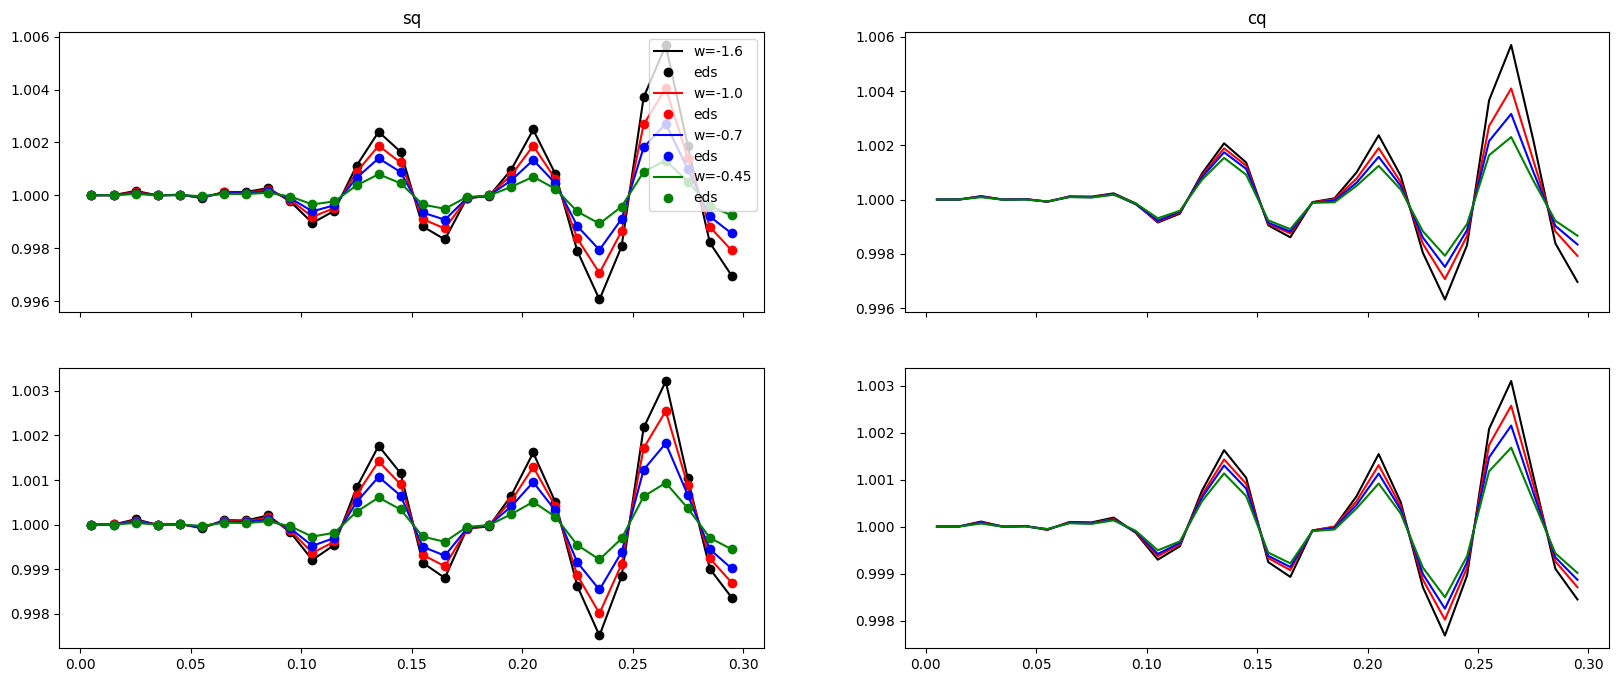

In [19]:
f,ax=plt.subplots(2,2,figsize=(20,8),sharex=True,sharey=False)
l=0
color=['k','r','b','g']

# wcdm
for iw in range(len(w)):
    for iz in range(len(zlist)):
        
        ax[iz][0].plot(kd,(ex_pk_wcdm[iw][iz][0][l]/ex_pk_wcdm_master[iw][iz][l]),color=color[iw],label='w={}'.format(w[iw]))
        ax[iz][0].plot(kd,(eds_pk_wcdm[iw][iz][0][l]/eds_pk_wcdm_master[iw][iz][l]),'o',color=color[iw],label='eds'.format(w[iw]))

        ax[iz][1].plot(kd,(ex_pk_wcdm_cq[iw][iz][0][l]/ex_pk_wcdm_cq_master[iw][iz][l]),color=color[iw],label='w={}'.format(w[iw]))
        
        

ax[0][0].set_title('sq')
ax[0][1].set_title('cq')
ax[0][0].legend()